In [4]:
# කැමරාව වැඩ කරනවාදැයි පරීක්ෂා කිරීම
import cv2

def test_webcam(index=0):
    """කැමරාව ක්‍රියා කරනවාදැයි පරීක්ෂා කරන්න"""
    cap = cv2.VideoCapture(index)
    if not cap.isOpened():
        print(f"❌ කැමරාව {index} විවෘත කළ නොහැක")
        return False
    
    ret, frame = cap.read()
    if ret:
        print(f"✅ කැමරාව {index} සාර්ථකයි!")
        print(f"   Resolution: {frame.shape[1]}x{frame.shape[0]}")
    else:
        print(f"❌ කැමරාවෙන් රූපයක් ලබාගත නොහැක")
    
    cap.release()
    return ret

# පරීක්ෂා කරන්න
test_webcam(0)

✅ කැමරාව 0 සාර්ථකයි!
   Resolution: 640x480


True

In [1]:
"""
Fabric Roll Width Quality Control System
==========================================
Real-time vision pipeline for measuring the physical width of an unrolling
fabric roll using an overhead camera and a checkerboard calibration marker.

Pipeline stages:
    1. Calibration        -> px-to-mm ratio from a known-size checkerboard
    2. Edge Detection      -> Canny + contour analysis for left/right edges
    3. Measurement         -> pixel distance * calibration ratio
    4. Self-Correction     -> linear extrapolation over last N frames when
                              an edge is occluded
    5. Monitoring Logic    -> consecutive-frame threshold alerting +
                              end-of-roll detection
    6. Telemetry           -> JSON frame records + time-series sink for
                              trend visualization / predictive maintenance

Dependencies: opencv-python, numpy
    pip install opencv-python numpy
"""

import subprocess
import sys
import os

def _ensure_dependency(module_name: str, pip_name: str = None):
    """Install a package on the fly if it isn't available yet."""
    try:
        __import__(module_name)
    except ImportError:
        pip_name = pip_name or module_name
        try:
            subprocess.check_call([
                sys.executable, "-m", "pip", "install", pip_name
            ])
        except:
            print(f"⚠️ Could not auto-install {pip_name}. Please install manually.")

_ensure_dependency("cv2", "opencv-python")
_ensure_dependency("numpy")

import cv2
import numpy as np
import json
import time
from collections import deque
from datetime import datetime, timezone
from dataclasses import dataclass, asdict
from typing import Optional, Tuple, List


# --------------------------------------------------------------------------
# Configuration
# --------------------------------------------------------------------------

@dataclass
class QCConfig:
    checkerboard_size: Tuple[int, int] = (7, 9)   # internal corners (rows, cols)
    checkerboard_square_mm: float = 20      # physical size per square (mm)
    target_width_mm: float = 1000.0                # nominal/spec fabric width
    min_width_threshold_mm: float = 950.0           # MIN_WIDTH_THRESHOLD
    consecutive_frames_for_failure: int = 3         # debounce for FAILURE status
    trajectory_history_len: int = 10                # frames used for extrapolation
    end_of_roll_width_mm: float = 50.0              # below this => END_OF_ROLL
    canny_low: int = 50
    canny_high: int = 150


# --------------------------------------------------------------------------
# Stage 1: Calibration
# --------------------------------------------------------------------------

class Calibrator:
    """Detects a checkerboard marker and derives the px-to-mm ratio."""

    def __init__(self, config: QCConfig):
        self.config = config
        self.px_to_mm: Optional[float] = None

    def calibrate(self, frame: np.ndarray) -> float:
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        found, corners = cv2.findChessboardCorners(
            gray, self.config.checkerboard_size,
            flags=cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_NORMALIZE_IMAGE
        )
        if not found:
            raise RuntimeError(
                "Calibration marker not detected in first frame. "
                "Check lighting, marker placement, or checkerboard_size config."
            )

        corners = cv2.cornerSubPix(
            gray, corners, (11, 11), (-1, -1),
            criteria=(cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 30, 0.001)
        )

        # Average spacing between adjacent corners horizontally, in pixels
        rows, cols = self.config.checkerboard_size
        pts = corners.reshape(-1, 2)
        horizontal_dists = []
        for r in range(rows):
            row_pts = pts[r * cols:(r + 1) * cols]
            for i in range(len(row_pts) - 1):
                horizontal_dists.append(np.linalg.norm(row_pts[i + 1] - row_pts[i]))

        avg_px_per_square = float(np.mean(horizontal_dists))
        self.px_to_mm = self.config.checkerboard_square_mm / avg_px_per_square
        return self.px_to_mm


# --------------------------------------------------------------------------
# Stage 2 & 3: Edge Detection + Measurement
# --------------------------------------------------------------------------

@dataclass
class EdgeReading:
    left_px: Optional[float]
    right_px: Optional[float]
    confidence: float          # 0-100
    extrapolated: bool          # True if self-correction was used


class EdgeDetector:
    """Finds left/right vertical fabric edges in a frame via Canny + contours."""

    def __init__(self, config: QCConfig):
        self.config = config

    def detect(self, frame: np.ndarray, roi_y: Optional[Tuple[int, int]] = None) -> EdgeReading:
        h, w = frame.shape[:2]
        y0, y1 = roi_y if roi_y else (0, h)
        roi = frame[y0:y1, :]

        gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        edges = cv2.Canny(blurred, self.config.canny_low, self.config.canny_high)

        # Sum edge activation per column -> columns with strong vertical
        # edge content correspond to the fabric's left/right boundaries.
        col_energy = edges.sum(axis=0).astype(np.float32)

        if col_energy.max() <= 0:
            # No edges found at all this frame
            return EdgeReading(left_px=None, right_px=None, confidence=0.0, extrapolated=False)

        threshold = 0.3 * col_energy.max()
        candidate_cols = np.where(col_energy > threshold)[0]

        if len(candidate_cols) < 2:
            return EdgeReading(left_px=None, right_px=None, confidence=0.0, extrapolated=False)

        left_px = float(candidate_cols.min())
        right_px = float(candidate_cols.max())

        # Confidence heuristic: how strong/clean the edge peaks are relative
        # to background noise in the column-energy profile.
        signal = col_energy[candidate_cols].mean()
        noise = col_energy[col_energy <= threshold].mean() if np.any(col_energy <= threshold) else 1.0
        snr = signal / (noise + 1e-6)
        confidence = float(np.clip(50 + 10 * np.log1p(snr), 0, 100))

        return EdgeReading(left_px=left_px, right_px=right_px, confidence=confidence, extrapolated=False)


# --------------------------------------------------------------------------
# Stage 4: Self-Correction (occlusion handling via trajectory extrapolation)
# --------------------------------------------------------------------------

class TrajectoryExtrapolator:
    """Keeps a rolling history of edge positions and linearly extrapolates
    when the current frame's edge detection fails (occlusion, dust, shadow)."""

    def __init__(self, config: QCConfig):
        self.config = config
        self.left_history: deque = deque(maxlen=config.trajectory_history_len)
        self.right_history: deque = deque(maxlen=config.trajectory_history_len)

    @staticmethod
    def _fit_and_predict(history: deque) -> Optional[float]:
        if len(history) < 2:
            return history[-1] if history else None
        xs = np.arange(len(history))
        ys = np.array(history)
        # Linear fit: position vs. frame index, predict next point
        slope, intercept = np.polyfit(xs, ys, 1)
        return float(slope * len(history) + intercept)

    def correct(self, reading: EdgeReading) -> EdgeReading:
        left, right = reading.left_px, reading.right_px
        extrapolated = False

        if left is None and self.left_history:
            left = self._fit_and_predict(self.left_history)
            extrapolated = True
        if right is None and self.right_history:
            right = self._fit_and_predict(self.right_history)
            extrapolated = True

        if left is not None:
            self.left_history.append(left)
        if right is not None:
            self.right_history.append(right)

        confidence = reading.confidence * 0.6 if extrapolated else reading.confidence
        return EdgeReading(left_px=left, right_px=right, confidence=confidence, extrapolated=extrapolated)


# --------------------------------------------------------------------------
# Stage 5: Monitoring Logic
# --------------------------------------------------------------------------

class WidthMonitor:
    """Applies threshold/debounce logic and end-of-roll detection."""

    def __init__(self, config: QCConfig):
        self.config = config
        self._below_threshold_streak = 0

    def evaluate(self, width_mm: Optional[float]) -> str:
        """Returns one of: OK, WARNING, FAILURE, END_OF_ROLL, UNKNOWN"""
        if width_mm is None:
            return "UNKNOWN"

        if width_mm <= self.config.end_of_roll_width_mm:
            self._below_threshold_streak = 0
            return "END_OF_ROLL"

        if width_mm < self.config.min_width_threshold_mm:
            self._below_threshold_streak += 1
            if self._below_threshold_streak >= self.config.consecutive_frames_for_failure:
                return "FAILURE"
            return "WARNING"

        self._below_threshold_streak = 0
        return "OK"


# --------------------------------------------------------------------------
# Stage 6: Telemetry / Time-series sink
# --------------------------------------------------------------------------

class TimeSeriesSink:
    """Placeholder for a real time-series DB (InfluxDB, TimescaleDB, etc)."""

    def __init__(self):
        self.buffer: List[dict] = []

    def write(self, record: dict):
        self.buffer.append(record)

    def flush(self):
        data, self.buffer = self.buffer, []
        return data


# --------------------------------------------------------------------------
# Orchestration: the full per-frame pipeline
# --------------------------------------------------------------------------

class FabricWidthQCSystem:
    def __init__(self, config: Optional[QCConfig] = None):
        self.config = config or QCConfig()
        self.calibrator = Calibrator(self.config)
        self.edge_detector = EdgeDetector(self.config)
        self.extrapolator = TrajectoryExtrapolator(self.config)
        self.monitor = WidthMonitor(self.config)
        self.sink = TimeSeriesSink()
        self._calibrated = False

    def calibrate_from_first_frame(self, frame: np.ndarray):
        self.calibrator.calibrate(frame)
        self._calibrated = True

    def process_frame(self, frame: np.ndarray, roi_y: Optional[Tuple[int, int]] = None) -> dict:
        if not self._calibrated:
            raise RuntimeError("System not calibrated. Call calibrate_from_first_frame() first.")

        raw_reading = self.edge_detector.detect(frame, roi_y=roi_y)
        reading = self.extrapolator.correct(raw_reading)

        width_mm = None
        if reading.left_px is not None and reading.right_px is not None:
            width_px = abs(reading.right_px - reading.left_px)
            width_mm = round(width_px * self.calibrator.px_to_mm, 2)

        status = self.monitor.evaluate(width_mm)
        deviation_mm = round(width_mm - self.config.target_width_mm, 2) if width_mm is not None else None

        record = {
            "timestamp": datetime.now(timezone.utc).isoformat(),
            "width_mm": width_mm,
            "confidence_score": round(reading.confidence, 1),
            "status": status,
            "deviation": f"{deviation_mm:+.1f}mm" if deviation_mm is not None else None,
            "extrapolated": reading.extrapolated,
        }

        self.sink.write({**record, "deviation_mm": deviation_mm})

        if status == "FAILURE":
            self._raise_failure_flag(record)
        if status == "END_OF_ROLL":
            self._handle_end_of_roll(record)

        return record

    def _raise_failure_flag(self, record: dict):
        print(f"[ALERT] Minimum Width Exceeded -> width={record['width_mm']}mm "
              f"at {record['timestamp']}")

    def _handle_end_of_roll(self, record: dict):
        print(f"[INFO] End of roll detected at {record['timestamp']}. Pausing measurement loop.")


# --------------------------------------------------------------------------
# ✅ FIXED: Example usage (video file or camera stream)
# --------------------------------------------------------------------------

def run_on_video(source, config: Optional[QCConfig] = None, roi_y: Optional[Tuple[int, int]] = None):
    """
    For pre-recorded video files / RTSP streams where frame 0 already
    contains the calibration marker.
    """
    cap = cv2.VideoCapture(source)
    if not cap.isOpened():
        raise IOError(f"Could not open video source: {source}")

    system = FabricWidthQCSystem(config)

    ret, first_frame = cap.read()
    if not ret:
        raise IOError("Could not read first frame for calibration.")
    system.calibrate_from_first_frame(first_frame)
    print(f"Calibration complete: {system.calibrator.px_to_mm:.5f} mm/px")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        record = system.process_frame(frame, roi_y=roi_y)
        print(json.dumps(record, indent=2))

        if record["status"] == "END_OF_ROLL":
            break

        time.sleep(0.01)

    cap.release()


def run_on_webcam(camera_index: int = 0, config: Optional[QCConfig] = None,
                   roi_y: Optional[Tuple[int, int]] = None):
    """
    Interactive live-webcam mode.

    Opens a preview window so you can position the checkerboard marker
    in frame. Controls:
        c -> calibrate using the current frame
        q -> quit
    """
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise IOError(
            f"Could not open webcam at index {camera_index}. "
            "Check that no other application is using the camera, "
            "and that your OS has granted camera permission to Python/Jupyter."
        )

    system = FabricWidthQCSystem(config)
    window_name = "Fabric QC - press 'c' to calibrate, 'q' to quit"

    print("Position the checkerboard marker in view, then press 'c' to calibrate.")
    while not system._calibrated:
        ret, frame = cap.read()
        if not ret:
            raise IOError("Failed to read frame from webcam.")

        preview = frame.copy()
        cv2.putText(preview, "Press 'c' to calibrate, 'q' to quit", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv2.imshow(window_name, preview)

        key = cv2.waitKey(1) & 0xFF
        if key == ord('c'):
            try:
                system.calibrate_from_first_frame(frame)
                print(f"Calibration complete: {system.calibrator.px_to_mm:.5f} mm/px")
            except RuntimeError as e:
                print(f"Calibration failed: {e}. Reposition the marker and try again.")
        elif key == ord('q'):
            cap.release()
            cv2.destroyAllWindows()
            return

    print("Calibration done. Starting live measurement loop (press 'q' to quit)...")
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        record = system.process_frame(frame, roi_y=roi_y)
        print(json.dumps(record, indent=2))

        overlay_text = f"{record['width_mm']} mm | {record['status']}"
        preview = frame.copy()
        color = (0, 255, 0) if record["status"] == "OK" else (0, 0, 255)
        cv2.putText(preview, overlay_text, (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, color, 2)
        cv2.imshow(window_name, preview)

        if record["status"] == "END_OF_ROLL":
            break
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    cap.release()
    cv2.destroyAllWindows()


# ============================================
# ✅ FIXED MAIN EXECUTION - JUPYTER NOTEBOOK READY
# ============================================

if __name__ == "__main__":
    import sys
    
    # ✅ FIX: Properly handle Jupyter Notebook environment
    # Check if running in Jupyter/Colab
    def is_jupyter_notebook():
        try:
            from IPython import get_ipython
            if get_ipython() is not None:
                return True
        except ImportError:
            pass
        return False
    
    in_notebook = is_jupyter_notebook()
    
    if in_notebook:
        # 🎯 JUPYTER NOTEBOOK MODE - Always use webcam
        print("📓 Running in Jupyter Notebook mode")
        print("📷 Using built-in webcam (index 0)")
        print("🔄 To use a video file, call run_on_video('path/to/video.mp4') directly")
        print("-" * 60)
        run_on_webcam(0)
    else:
        # 💻 COMMAND LINE MODE
        if len(sys.argv) > 1:
            # A path/URL was passed -> treat as a video file / stream
            # Skip if it's a Jupyter flag like -f
            arg = sys.argv[1]
            if arg.startswith('-'):
                print(f"⚠️  Ignoring flag: {arg}")
                print("📷 Using webcam instead...")
                run_on_webcam(0)
            else:
                run_on_video(arg)
        else:
            # No argument -> default to interactive local webcam mode
            run_on_webcam(0)

📓 Running in Jupyter Notebook mode
📷 Using built-in webcam (index 0)
🔄 To use a video file, call run_on_video('path/to/video.mp4') directly
------------------------------------------------------------
Position the checkerboard marker in view, then press 'c' to calibrate.
Calibration complete: 0.41249 mm/px
Calibration done. Starting live measurement loop (press 'q' to quit)...
{
  "timestamp": "2026-07-09T15:22:32.668605+00:00",
  "width_mm": 157.57,
  "confidence_score": 66.2,
  "status": "WARNING",
  "deviation": "-842.4mm",
  "extrapolated": false
}
{
  "timestamp": "2026-07-09T15:22:32.692877+00:00",
  "width_mm": 157.16,
  "confidence_score": 65.8,
  "status": "WARNING",
  "deviation": "-842.8mm",
  "extrapolated": false
}
[ALERT] Minimum Width Exceeded -> width=157.16mm at 2026-07-09T15:22:32.725891+00:00
{
  "timestamp": "2026-07-09T15:22:32.725891+00:00",
  "width_mm": 157.16,
  "confidence_score": 65.4,
  "status": "FAILURE",
  "deviation": "-842.8mm",
  "extrapolated": false


In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import json
import time
from datetime import datetime
import tkinter as tk
from tkinter import messagebox

# ---- 1. Configuration ----
CALIB_IMAGES_DIR = "calibration_images"      # folder of checkerboard photos
CALIB_PARAMS_FILE = "camera_calibration.json"
CHECKERBOARD = (9, 6)                        # inner corners (cols, rows)
SQUARE_SIZE_MM = 25.0                        # real-world size of one checkerboard square (mm)

SCAN_LOG_CSV = "fabric_width_log.csv"
CAMERA_INDEX = 0

WHITE_THRESHOLD = 200        # grayscale value considered "white"
WHITE_RATIO_STOP = 0.95      # fraction of white pixels that triggers "background only" stop
FABRIC_THRESH = 127          # binary threshold to separate fabric from background

os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)
print("Configuration loaded.")

# ---- 2. Calibration Loader ----
def load_calibration():
    """Loads saved calibration parameters, or returns sensible defaults."""
    if os.path.exists(CALIB_PARAMS_FILE):
        with open(CALIB_PARAMS_FILE, "r") as f:
            data = json.load(f)
        camera_matrix = np.array(data["camera_matrix"])
        dist_coeffs = np.array(data["dist_coeffs"])
        pixel_to_mm_scale = data["pixel_to_mm_scale"]
        print(f"Loaded calibration (scale = {pixel_to_mm_scale:.5f} mm/px).")
        return camera_matrix, dist_coeffs, pixel_to_mm_scale
    else:
        print("No calibration file found - using uncalibrated defaults (scale = 1.0 mm/px).")
        return None, None, 1.0

# Load calibration initially
camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

# ---- 3. Core Measurement Functions ----
def undistort_frame(frame, camera_matrix, dist_coeffs):
    if camera_matrix is None or dist_coeffs is None:
        return frame
    return cv2.undistort(frame, camera_matrix, dist_coeffs)

def is_white_background(frame, threshold=WHITE_THRESHOLD, white_ratio=WHITE_RATIO_STOP):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    white_pixels = cv2.countNonZero(thresh)
    total_pixels = thresh.size
    return (white_pixels / total_pixels) > white_ratio

def measure_width_px(frame, fabric_thresh=FABRIC_THRESH):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, fabric_thresh, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None

    cnt = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 500:  
        return None, None

    x, y, w, h = cv2.boundingRect(cnt)
    return w, (x, y, w, h)

# ---- 4. Post-Scan Analysis & Plotting ----
def analyze_and_plot_scan(csv_path=SCAN_LOG_CSV):
    """Automatically analyzes the CSV log and generates the graph."""
    if not os.path.exists(csv_path):
        print(f"No log file found at {csv_path}.")
        return

    df = pd.read_csv(csv_path)
    if df.empty:
        print("Log file is empty - no measurements to analyze.")
        return

    min_row = df.loc[df["width_mm"].idxmin()]
    summary = {
        "num_frames": len(df),
        "min_width_mm": float(df["width_mm"].min()),
        "min_width_frame": int(min_row["frame"]),
        "max_width_mm": float(df["width_mm"].max()),
        "mean_width_mm": float(df["width_mm"].mean()),
        "std_width_mm": float(df["width_mm"].std()),
    }

    print("\n=== Fabric Roll Width Summary ===")
    print(f"Frames analyzed : {summary['num_frames']}")
    print(f"Minimum width   : {summary['min_width_mm']:.2f} mm  (at frame {summary['min_width_frame']})")
    print(f"Maximum width   : {summary['max_width_mm']:.2f} mm")
    print(f"Mean width      : {summary['mean_width_mm']:.2f} mm")
    print(f"Std deviation   : {summary['std_width_mm']:.2f} mm\n")
    print(f">>> Recommended cutting-lay width: {summary['min_width_mm']:.2f} mm")

    # Generate Plot Automatically
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df["frame"], df["width_mm"], color="#1f77b4", linewidth=1.5, label="Width per frame")
    ax.axhline(summary["min_width_mm"], color="red", linestyle="--", label=f"Minimum = {summary['min_width_mm']:.2f} mm")
    ax.axhline(summary["mean_width_mm"], color="green", linestyle=":", label=f"Mean = {summary['mean_width_mm']:.2f} mm")
    ax.scatter([summary["min_width_frame"]], [summary["min_width_mm"]], color="red", zorder=5, s=60)

    ax.set_xlabel("Frame index (position along roll)")
    ax.set_ylabel("Width (mm)")
    ax.set_title("Fabric Roll Width Profile")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    
    # Save and Show Plot
    plot_filename = "fabric_width_profile.png"
    plt.savefig(plot_filename, dpi=150)
    print(f"Plot saved automatically to {plot_filename}")
    plt.show(block=False) # Open in background without freezing the GUI
    plt.pause(3)          # Keep it open for 3 seconds
    plt.close()

# ---- 5. Live Capture & Scan Loop ----
def run_scan(camera_index=CAMERA_INDEX, show_preview=True, max_frames=None):
    # Reload calibration values in case they changed
    global camera_matrix, dist_coeffs, pixel_to_mm_scale
    camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError("Could not open camera. Please check the connection.")

    records = []
    frame_idx = 0
    start_time = datetime.now()

    print("Scanning started. Move the camera along the fabric roll...")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Camera read failed - stopping.")
            break

        frame_u = undistort_frame(frame, camera_matrix, dist_coeffs)

        if is_white_background(frame_u):
            print(f"White background detected at frame {frame_idx} - end of roll, stopping capture.")
            break

        width_px, bbox = measure_width_px(frame_u)
        timestamp = datetime.now().isoformat()

        if width_px is not None:
            width_mm = width_px * pixel_to_mm_scale
            records.append({
                "frame": frame_idx,
                "timestamp": timestamp,
                "width_px": width_px,
                "width_mm": round(width_mm, 2),
            })
            if show_preview:
                x, y, w, h = bbox
                cv2.rectangle(frame_u, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(frame_u, f"{width_mm:.1f} mm", (x, max(y - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        if show_preview:
            cv2.imshow("Fabric Scan (press q to stop early)", frame_u)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("Stopped manually by user.")
                break

        frame_idx += 1
        if max_frames is not None and frame_idx >= max_frames:
            break

    cap.release()
    if show_preview:
        cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(SCAN_LOG_CSV, index=False)
    print(f"Scan finished. {len(df)} frames logged.")
    
    # TRIGGER AUTOMATIC ANALYSIS AFTER SCAN
    analyze_and_plot_scan()
    
    return df

# ---- 6. GUI Setup ----
def launch_start_gui(on_start_callback):
    root = tk.Tk()
    root.title("Fabric Roll Width Scanner")
    root.geometry("340x180")
    root.resizable(False, False)

    status_var = tk.StringVar(value="Ready. Press Start to begin scanning.")

    def handle_start():
        status_var.set("Scanning... check the camera window.")
        start_btn.config(state=tk.DISABLED)
        root.update()
        try:
            on_start_callback()
            status_var.set("Scan & Analysis complete! Graph saved.")
        except Exception as e:
            messagebox.showerror("Scan error", str(e))
            status_var.set("Scan failed.")
        finally:
            start_btn.config(state=tk.NORMAL)

    title_lbl = tk.Label(root, text=\"Fabric Roll Width Scanner\", font=(\"Segoe UI\", 13, \"bold\"))
    title_lbl.pack(pady=(15, 5))

    status_lbl = tk.Label(root, textvariable=status_var, wraplength=300, fg=\"#444\")
    status_lbl.pack(pady=(0, 10))

    start_btn = tk.Button(root, text=\"Start\", width=15, height=2,
                           bg=\"#2e7d32\", fg=\"white\", font=(\"Segoe UI\", 11, \"bold\"),
                           command=handle_start)
    start_btn.pack(pady=5)

    quit_btn = tk.Button(root, text=\"Close\", width=15, command=root.destroy)
    quit_btn.pack(pady=(5, 10))

    root.mainloop()

# ---- 7. Execution ----
if __name__ == "__main__":
    launch_start_gui(run_scan)

SyntaxError: unexpected character after line continuation character (3414118338.py, line 222)

Configuration loaded.
No calibration file found - using uncalibrated defaults (scale = 1.0 mm/px).
No calibration file found - using uncalibrated defaults (scale = 1.0 mm/px).
Scanning started. Move the camera along the fabric roll...
Stopped manually by user.
Scan finished. 1107 frames logged.

=== Fabric Roll Width Summary ===
Frames analyzed : 1107
Minimum width   : 166.00 mm  (at frame 1035)
Maximum width   : 640.00 mm
Mean width      : 432.24 mm
Std deviation   : 109.99 mm

>>> Recommended cutting-lay width: 166.00 mm
Plot saved automatically to fabric_width_profile.png


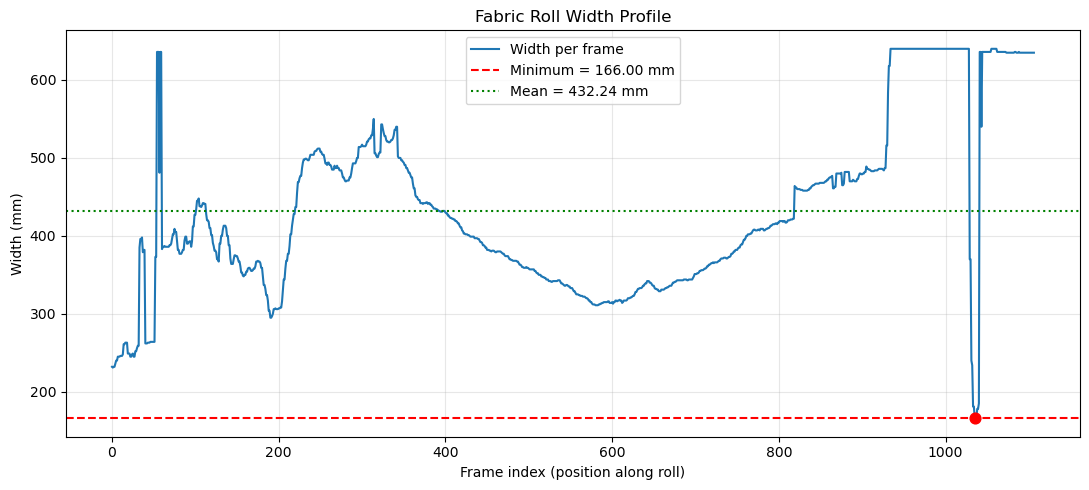

In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import json
import time
from datetime import datetime
import tkinter as tk
from tkinter import messagebox

# ---- 1. Configuration ----
CALIB_IMAGES_DIR = "calibration_images"      # folder of checkerboard photos
CALIB_PARAMS_FILE = "camera_calibration.json"
CHECKERBOARD = (9, 6)                        # inner corners (cols, rows)
SQUARE_SIZE_MM = 25.0                        # real-world size of one checkerboard square (mm)

SCAN_LOG_CSV = "fabric_width_log.csv"
CAMERA_INDEX = 0

WHITE_THRESHOLD = 200        # grayscale value considered "white"
WHITE_RATIO_STOP = 0.95      # fraction of white pixels that triggers "background only" stop
FABRIC_THRESH = 127          # binary threshold to separate fabric from background

os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)
print("Configuration loaded.")

# ---- 2. Calibration Loader ----
def load_calibration():
    """Loads saved calibration parameters, or returns sensible defaults."""
    if os.path.exists(CALIB_PARAMS_FILE):
        with open(CALIB_PARAMS_FILE, "r") as f:
            data = json.load(f)
        camera_matrix = np.array(data["camera_matrix"])
        dist_coeffs = np.array(data["dist_coeffs"])
        pixel_to_mm_scale = data["pixel_to_mm_scale"]
        print(f"Loaded calibration (scale = {pixel_to_mm_scale:.5f} mm/px).")
        return camera_matrix, dist_coeffs, pixel_to_mm_scale
    else:
        print("No calibration file found - using uncalibrated defaults (scale = 1.0 mm/px).")
        return None, None, 1.0

# Load calibration initially
camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

# ---- 3. Core Measurement Functions ----
def undistort_frame(frame, camera_matrix, dist_coeffs):
    if camera_matrix is None or dist_coeffs is None:
        return frame
    return cv2.undistort(frame, camera_matrix, dist_coeffs)

def is_white_background(frame, threshold=WHITE_THRESHOLD, white_ratio=WHITE_RATIO_STOP):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    white_pixels = cv2.countNonZero(thresh)
    total_pixels = thresh.size
    return (white_pixels / total_pixels) > white_ratio

def measure_width_px(frame, fabric_thresh=FABRIC_THRESH):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, fabric_thresh, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None

    cnt = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 500:  
        return None, None

    x, y, w, h = cv2.boundingRect(cnt)
    return w, (x, y, w, h)

# ---- 4. Post-Scan Analysis & Plotting ----
def analyze_and_plot_scan(csv_path=SCAN_LOG_CSV):
    """Automatically analyzes the CSV log and generates the graph."""
    if not os.path.exists(csv_path):
        print(f"No log file found at {csv_path}.")
        return

    df = pd.read_csv(csv_path)
    if df.empty:
        print("Log file is empty - no measurements to analyze.")
        return

    min_row = df.loc[df["width_mm"].idxmin()]
    summary = {
        "num_frames": len(df),
        "min_width_mm": float(df["width_mm"].min()),
        "min_width_frame": int(min_row["frame"]),
        "max_width_mm": float(df["width_mm"].max()),
        "mean_width_mm": float(df["width_mm"].mean()),
        "std_width_mm": float(df["width_mm"].std()),
    }

    print("\n=== Fabric Roll Width Summary ===")
    print(f"Frames analyzed : {summary['num_frames']}")
    print(f"Minimum width   : {summary['min_width_mm']:.2f} mm  (at frame {summary['min_width_frame']})")
    print(f"Maximum width   : {summary['max_width_mm']:.2f} mm")
    print(f"Mean width      : {summary['mean_width_mm']:.2f} mm")
    print(f"Std deviation   : {summary['std_width_mm']:.2f} mm\n")
    print(f">>> Recommended cutting-lay width: {summary['min_width_mm']:.2f} mm")

    # Generate Plot Automatically
    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df["frame"], df["width_mm"], color="#1f77b4", linewidth=1.5, label="Width per frame")
    ax.axhline(summary["min_width_mm"], color="red", linestyle="--", label=f"Minimum = {summary['min_width_mm']:.2f} mm")
    ax.axhline(summary["mean_width_mm"], color="green", linestyle=":", label=f"Mean = {summary['mean_width_mm']:.2f} mm")
    ax.scatter([summary["min_width_frame"]], [summary["min_width_mm"]], color="red", zorder=5, s=60)

    ax.set_xlabel("Frame index (position along roll)")
    ax.set_ylabel("Width (mm)")
    ax.set_title("Fabric Roll Width Profile")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    
    # Save and Show Plot
    plot_filename = "fabric_width_profile.png"
    plt.savefig(plot_filename, dpi=150)
    print(f"Plot saved automatically to {plot_filename}")
    plt.show(block=False)
    plt.pause(3)
    plt.close()

# ---- 5. Live Capture & Scan Loop ----
def run_scan(camera_index=CAMERA_INDEX, show_preview=True, max_frames=None):
    global camera_matrix, dist_coeffs, pixel_to_mm_scale
    camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        raise RuntimeError("Could not open camera. Please check the connection.")

    records = []
    frame_idx = 0
    start_time = datetime.now()

    print("Scanning started. Move the camera along the fabric roll...")

    while True:
        ret, frame = cap.read()
        if not ret:
            print("Camera read failed - stopping.")
            break

        frame_u = undistort_frame(frame, camera_matrix, dist_coeffs)

        if is_white_background(frame_u):
            print(f"White background detected at frame {frame_idx} - end of roll, stopping capture.")
            break

        width_px, bbox = measure_width_px(frame_u)
        timestamp = datetime.now().isoformat()

        if width_px is not None:
            width_mm = width_px * pixel_to_mm_scale
            records.append({
                "frame": frame_idx,
                "timestamp": timestamp,
                "width_px": width_px,
                "width_mm": round(width_mm, 2),
            })
            if show_preview:
                x, y, w, h = bbox
                cv2.rectangle(frame_u, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(frame_u, f"{width_mm:.1f} mm", (x, max(y - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        if show_preview:
            cv2.imshow("Fabric Scan (press q to stop early)", frame_u)
            if cv2.waitKey(1) & 0xFF == ord('q'):
                print("Stopped manually by user.")
                break

        frame_idx += 1
        if max_frames is not None and frame_idx >= max_frames:
            break

    cap.release()
    if show_preview:
        cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(SCAN_LOG_CSV, index=False)
    print(f"Scan finished. {len(df)} frames logged.")
    
    analyze_and_plot_scan()
    
    return df

# ---- 6. GUI Setup ----
def launch_start_gui(on_start_callback):
    root = tk.Tk()
    root.title("Fabric Roll Width Scanner")
    root.geometry("340x180")
    root.resizable(False, False)

    status_var = tk.StringVar(value="Ready. Press Start to begin scanning.")

    def handle_start():
        status_var.set("Scanning... check the camera window.")
        start_btn.config(state=tk.DISABLED)
        root.update()
        try:
            on_start_callback()
            status_var.set("Scan & Analysis complete! Graph saved.")
        except Exception as e:
            messagebox.showerror("Scan error", str(e))
            status_var.set("Scan failed.")
        finally:
            start_btn.config(state=tk.NORMAL)

    title_lbl = tk.Label(root, text="Fabric Roll Width Scanner", font=("Segoe UI", 13, "bold"))
    title_lbl.pack(pady=(15, 5))

    status_lbl = tk.Label(root, textvariable=status_var, wraplength=300, fg="#444")
    status_lbl.pack(pady=(0, 10))

    start_btn = tk.Button(root, text="Start", width=15, height=2,
                           bg="#2e7d32", fg="white", font=("Segoe UI", 11, "bold"),
                           command=handle_start)
    start_btn.pack(pady=5)

    quit_btn = tk.Button(root, text="Close", width=15, command=root.destroy)
    quit_btn.pack(pady=(5, 10))

    root.mainloop()

# ---- 7. Execution ----
if __name__ == "__main__":
    launch_start_gui(run_scan)

In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import time
from datetime import datetime
import tkinter as tk
from tkinter import messagebox

# ---- 1. Configuration & ChArUco Setup ----
CALIB_IMAGES_DIR = "calibration_images"
CALIB_PARAMS_FILE = "camera_calibration.json"
SCAN_LOG_CSV = "fabric_width_log.csv"
CAMERA_INDEX = 0

# ChArUco Board Parameters (Adjust based on your printout)
CHARUCO_DICT = cv2.aruco.DICT_6X6_250         # ArUco dictionary type
SQUARES_X = 7                                # Number of squares horizontally
SQUARES_Y = 5                                # Number of squares vertically
SQUARE_LENGTH_MM = 30.0                      # Real-world size of checker square side (mm)
MARKER_LENGTH_MM = 15.0                      # Real-world size of ArUco marker side (mm)

WHITE_THRESHOLD = 200        
WHITE_RATIO_STOP = 0.95      
FABRIC_THRESH = 127          

os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)

# Instantiate ChArUco objects using updated OpenCV 4.x/5.x syntax
dictionary = cv2.aruco.getPredefinedDictionary(CHARUCO_DICT)
charuco_board = cv2.aruco.CharucoBoard((SQUARES_X, SQUARES_Y), SQUARE_LENGTH_MM, MARKER_LENGTH_MM, dictionary)
aruco_detector = cv2.aruco.ArucoDetector(dictionary, cv2.aruco.DetectorParameters())

# Automatically create a printable ChArUco board image if it doesn't exist
if not os.path.exists("charuco_board.png"):
    # Generate a high-res image of the board to print out
    board_img = charuco_board.generateImage((1000, 750), marginSize=20)
    cv2.imwrite("charuco_board.png", board_img)
    print("Generated 'charuco_board.png'. Print this flat surface to use for calibration.")

print("Configuration loaded.")

# ---- 2. ChArUco Calibration Methods ----
def capture_calibration_images(num_images=15, camera_index=CAMERA_INDEX):
    """Opens webcam to capture ChArUco images. Press SPACE to capture, ESC to exit."""
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("Could not open camera.")
        return

    count = 0
    print(f"Show ChArUco board. SPACE = capture, ESC = stop. Target: {num_images} images.")

    while count < num_images:
        ret, frame = cap.read()
        if not ret: break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        marker_corners, marker_ids, _ = aruco_detector.detectMarkers(gray)
        
        display = frame.copy()
        if marker_ids is not None and len(marker_ids) > 0:
            cv2.aruco.drawDetectedMarkers(display, marker_corners, marker_ids)
            # Try to interpolate corners
            ret_c, c_corners, c_ids = cv2.aruco.interpolateCornersCharuco(marker_corners, marker_ids, gray, charuco_board)
            if ret_c > 0:
                cv2.aruco.drawDetectedCornersCharuco(display, c_corners, c_ids)
                cv2.putText(display, "ChArUco FOUND - press SPACE", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        cv2.putText(display, f"Captured: {count}/{num_images}", (10, 60), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        cv2.imshow("ChArUco Calibration Capture", display)

        key = cv2.waitKey(1) & 0xFF
        if key == 27: 
            break
        elif key == 32 and marker_ids is not None and len(marker_ids) > 0:
            fname = os.path.join(CALIB_IMAGES_DIR, f"charuco_{count:02d}.png")
            cv2.imwrite(fname, frame)
            print(f"Saved {fname}")
            count += 1
            time.sleep(0.4)

    cap.release()
    cv2.destroyAllWindows()

def compute_camera_calibration():
    """Calibrates camera using collected ChArUco images."""
    import glob
    images = sorted(glob.glob(os.path.join(CALIB_IMAGES_DIR, "charuco_*.png")))
    if not images:
        print("No ChArUco calibration images found. Run capture_calibration_images() first.")
        return None

    all_charuco_corners = []
    all_charuco_ids = []
    img_shape = None

    for fname in images:
        img = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_shape = gray.shape[::-1]

        marker_corners, marker_ids, _ = aruco_detector.detectMarkers(gray)
        if marker_ids is not None and len(marker_ids) > 0:
            ret_c, c_corners, c_ids = cv2.aruco.interpolateCornersCharuco(marker_corners, marker_ids, gray, charuco_board)
            if ret_c > 3:  # Requires at least 4 successful corner matches
                all_charuco_corners.append(c_corners)
                all_charuco_ids.append(c_ids)

    if len(all_charuco_corners) < 5:
        print("Not enough valid patterns detected. Capture more angles.")
        return None

    # Calibrate using ChArUco specialized solver
    ret, camera_matrix, dist_coeffs, _, _ = cv2.aruco.calibrateCameraCharuco(
        all_charuco_corners, all_charuco_ids, charuco_board, img_shape, None, None
    )

    # Calculate real mm per pixel scale factor from detected squares
    all_px_dist = []
    for corners in all_charuco_corners:
        pts = corners.squeeze()
        if pts.ndim == 2 and len(pts) > 1:
            dists = np.linalg.norm(pts[1:] - pts[:-1], axis=1)
            all_px_dist.append(np.mean(dists))
    
    mean_px_dist = float(np.mean(all_px_dist)) if all_px_dist else 1.0
    # Because ChArUco IDs map to sequential grid points, adjacent entries roughly correspond to square intervals
    pixel_to_mm_scale = SQUARE_SIZE_MM / mean_px_dist

    calib_data = {
        "reprojection_error": float(ret),
        "camera_matrix": camera_matrix.tolist(),
        "dist_coeffs": dist_coeffs.tolist(),
        "pixel_to_mm_scale": pixel_to_mm_scale,
        "calibrated_at": datetime.now().isoformat(),
    }

    with open(CALIB_PARAMS_FILE, "w") as f:
        json.dump(calib_data, f, indent=2)

    print(f"Calibration Complete! Error: {ret:.4f} | Scale: {pixel_to_mm_scale:.5f} mm/px")
    return calib_data

def load_calibration():
    if os.path.exists(CALIB_PARAMS_FILE):
        with open(CALIB_PARAMS_FILE, "r") as f:
            data = json.load(f)
        return np.array(data["camera_matrix"]), np.array(data["dist_coeffs"]), data["pixel_to_mm_scale"]
    return None, None, 1.0

camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

# ---- 3. Core Measurement Functions ----
def undistort_frame(frame, camera_matrix, dist_coeffs):
    if camera_matrix is None or dist_coeffs is None: return frame
    return cv2.undistort(frame, camera_matrix, dist_coeffs)

def is_white_background(frame, threshold=WHITE_THRESHOLD, white_ratio=WHITE_RATIO_STOP):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return (cv2.countNonZero(thresh) / thresh.size) > white_ratio

def measure_width_px(frame, fabric_thresh=FABRIC_THRESH):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, fabric_thresh, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None, None

    cnt = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 500: return None, None

    x, y, w, h = cv2.boundingRect(cnt)
    return w, (x, y, w, h)

# ---- 4. Analysis & Plotting ----
def analyze_and_plot_scan(csv_path=SCAN_LOG_CSV):
    if not os.path.exists(csv_path): return
    df = pd.read_csv(csv_path)
    if df.empty: return

    min_row = df.loc[df["width_mm"].idxmin()]
    summary = {
        "num_frames": len(df),
        "min_width_mm": float(df["width_mm"].min()),
        "min_width_frame": int(min_row["frame"]),
        "max_width_mm": float(df["width_mm"].max()),
        "mean_width_mm": float(df["width_mm"].mean()),
    }

    print("\n=== Upgraded Scan Summary ===")
    print(f"Minimum width   : {summary['min_width_mm']:.2f} mm  (Frame {summary['min_width_frame']})")
    print(f"Mean width      : {summary['mean_width_mm']:.2f} mm")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df["frame"], df["width_mm"], color="#1f77b4", label="Width per frame")
    ax.axhline(summary["min_width_mm"], color="red", linestyle="--", label=f"True Min = {summary['min_width_mm']:.2f} mm")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fabric_width_profile.png", dpi=150)
    plt.show(block=False)
    plt.pause(3)
    plt.close()

# ---- 5. Live Capture & Scan Loop ----
def run_scan(camera_index=CAMERA_INDEX, show_preview=True):
    global camera_matrix, dist_coeffs, pixel_to_mm_scale
    camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened(): raise RuntimeError("Could not open camera.")

    records = []
    frame_idx = 0
    print("Scanning started along fabric roll...")

    while True:
        ret, frame = cap.read()
        if not ret: break

        frame_u = undistort_frame(frame, camera_matrix, dist_coeffs)
        if is_white_background(frame_u): break

        width_px, bbox = measure_width_px(frame_u)
        if width_px is not None:
            width_mm = width_px * pixel_to_mm_scale
            records.append({
                "frame": frame_idx,
                "timestamp": datetime.now().isoformat(),
                "width_px": width_px,
                "width_mm": round(width_mm, 2),
            })
            if show_preview:
                x, y, w, h = bbox
                cv2.rectangle(frame_u, (x, y), (x + w, y + h), (0, 255, 0), 2)

        if show_preview:
            cv2.imshow("Fabric Scan (Press q to exit)", frame_u)
            if cv2.waitKey(1) & 0xFF == ord('q'): break
        frame_idx += 1

    cap.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(SCAN_LOG_CSV, index=False)
    analyze_and_plot_scan()

# ---- 6. GUI Setup ----
def launch_start_gui(on_start_callback):
    root = tk.Tk()
    root.title("Fabric Roll Width Scanner")
    root.geometry("360x220")
    
    status_var = tk.StringVar(value="Ready. Run Calibration or Start Scan.")

    def run_calib_ui():
        status_var.set("Capturing images... Press SPACE on the camera preview window.")
        root.update()
        capture_calibration_images(num_images=12)
        status_var.set("Computing intrinsic matrix...")
        root.update()
        res = compute_camera_calibration()
        if res:
            status_var.set(f"Calibrated successfully! Err: {res['reprojection_error']:.3f}")
        else:
            status_var.set("Calibration failed. Try again.")

    tk.Label(root, text="ChArUco Fabric Scanner", font=("Segoe UI", 12, "bold")).pack(pady=10)
    tk.Label(root, textvariable=status_var, fg="#333", wraplength=320).pack(pady=5)
    
    tk.Button(root, text="1. Run ChArUco Calibration", command=run_calib_ui, bg="#0288d1", fg="white", width=25).pack(pady=5)
    tk.Button(root, text="2. Start Fabric Scan", command=on_start_callback, bg="#2e7d32", fg="white", width=25).pack(pady=5)
    tk.Button(root, text="Close", command=root.destroy, width=15).pack(pady=5)

    root.mainloop()

if __name__ == "__main__":
    launch_start_gui(run_scan)

Configuration loaded.
Show ChArUco board. SPACE = capture, ESC = stop. Target: 12 images.
No ChArUco calibration images found. Run capture_calibration_images() first.
Show ChArUco board. SPACE = capture, ESC = stop. Target: 12 images.
Scanning started along fabric roll...
No ChArUco calibration images found. Run capture_calibration_images() first.


Exception in Tkinter callback
Traceback (most recent call last):
  File "C:\anaconda\Lib\tkinter\__init__.py", line 2074, in __call__
    return self.func(*args)
           ~~~~~~~~~^^^^^^^
  File "C:\Users\ASIRI\AppData\Local\Temp\ipykernel_21356\2818790240.py", line 248, in run_scan
    if cv2.waitKey(1) & 0xFF == ord('q'): break
       ~~~~~~~~~~~^^^
KeyboardInterrupt


Configuration loaded for 7x9 Checkerboard.
Show the checkerboard. SPACE = capture, ESC = stop. Target: 15 images.
Saved calibration_images\calib_00.png
Saved calibration_images\calib_01.png
Saved calibration_images\calib_02.png
Saved calibration_images\calib_03.png
Saved calibration_images\calib_04.png
Saved calibration_images\calib_05.png
Saved calibration_images\calib_06.png
Saved calibration_images\calib_07.png
Saved calibration_images\calib_08.png
Saved calibration_images\calib_09.png
Saved calibration_images\calib_10.png
Saved calibration_images\calib_11.png
Saved calibration_images\calib_12.png
Saved calibration_images\calib_13.png
Saved calibration_images\calib_14.png
Calibration successful! Error: 0.2844 | Scale: 0.39550 mm/px
Scanning started...

=== Scan Analysis (High Accuracy) ===
Minimum Width   : 37.57 mm
Mean Width      : 184.71 mm


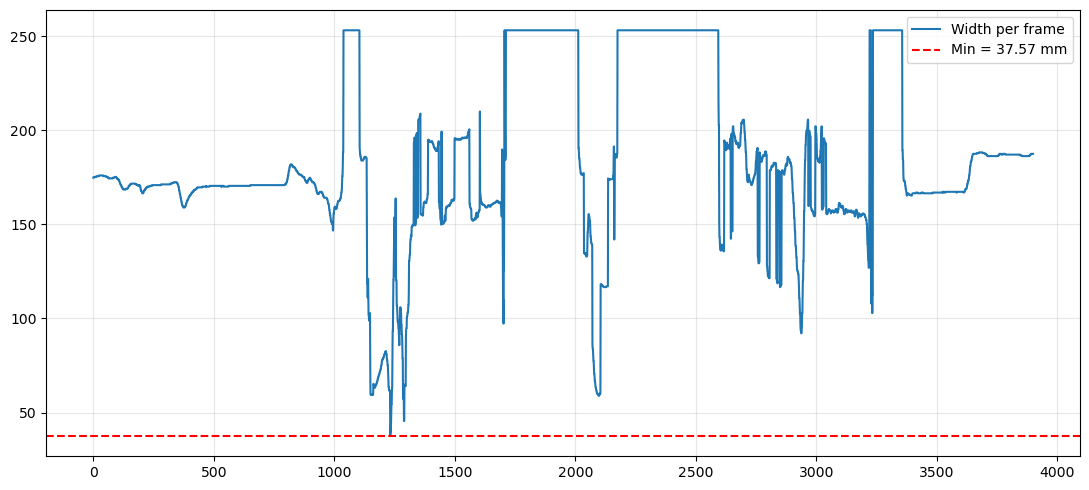

In [2]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import json
import time
from datetime import datetime
import tkinter as tk
from tkinter import messagebox

# ---- 1. Configuration (Updated for 7x9 Board) ----
CALIB_IMAGES_DIR = "calibration_images"      
CALIB_PARAMS_FILE = "camera_calibration.json"

# !!! වැදගත්: 7x9 බෝඩ් එකක inner corners වන්නේ (8, 6) හෝ (6, 8) වේ.
# ඔබගේ බෝඩ් එක දිගටි පැත්ත තිරස් අතට (Horizontal) තබා පින්තූර ගන්නේ නම් (8, 6) යොදන්න.
CHECKERBOARD = (8, 6)                        

# ඔබ ප්‍රින්ට් කර ඇති බෝඩ් එකේ එක කොටුවක නියම පළල මිලිමීටර (mm) වලින් මෙතැනට දෙන්න.
# (උදාහරණයක් ලෙස 25mm හෝ 30mm)
SQUARE_SIZE_MM = 21.0                        

SCAN_LOG_CSV = "fabric_width_log.csv"
CAMERA_INDEX = 0

WHITE_THRESHOLD = 200        
WHITE_RATIO_STOP = 0.95      
FABRIC_THRESH = 127          

os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)
print("Configuration loaded for 7x9 Checkerboard.")

# ---- 2. High-Accuracy Camera Calibration ----
def capture_calibration_images(num_images=15, camera_index=CAMERA_INDEX):
    """Opens the webcam to capture checkerboard images. Press SPACE to capture."""
    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened():
        print("Could not open camera.")
        return

    count = 0
    print(f"Show the checkerboard. SPACE = capture, ESC = stop. Target: {num_images} images.")

    while count < num_images:
        ret, frame = cap.read()
        if not ret: break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        # Find corners
        found, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, 
                                                   cv2.CALIB_CB_ADAPTIVE_THRESH + cv2.CALIB_CB_FAST_CHECK + cv2.CALIB_CB_NORMALIZE_IMAGE)

        display = frame.copy()
        if found:
            cv2.drawChessboardCorners(display, CHECKERBOARD, corners, found)
            cv2.putText(display, "FOUND - press SPACE to capture", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
        else:
            cv2.putText(display, "Searching for Checkerboard...", (10, 30),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        cv2.putText(display, f"Captured: {count}/{num_images}", (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)
        cv2.imshow("High-Res Calibration Capture", display)

        key = cv2.waitKey(1) & 0xFF
        if key == 27:  # ESC
            break
        elif key == 32 and found:  # SPACE
            fname = os.path.join(CALIB_IMAGES_DIR, f"calib_{count:02d}.png")
            cv2.imwrite(fname, frame)
            print(f"Saved {fname}")
            count += 1
            time.sleep(0.4)

    cap.release()
    cv2.destroyAllWindows()

def compute_camera_calibration():
    """Computes high-accuracy calibration matrix using Sub-Pixel corner refinement."""
    objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
    objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)
    objp *= SQUARE_SIZE_MM

    objpoints = []
    imgpoints = []

    images = sorted(glob.glob(os.path.join(CALIB_IMAGES_DIR, "calib_*.png")))
    if not images:
        print("No calibration images found!")
        return None

    # Sub-pixel accuracy criteria
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.0001)
    img_shape = None

    for fname in images:
        img = cv2.imread(fname)
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        img_shape = gray.shape[::-1]

        found, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)
        if found:
            # INCREASE ACCURACY: Sub-pixel refinement handles lens blur
            corners_refined = cv2.cornerSubPix(gray, corners, (11, 11), (-1, -1), criteria)
            objpoints.append(objp)
            imgpoints.append(corners_refined)

    if len(objpoints) < 5:
        print("Too few valid images for stable calibration.")
        return None

    # Calibrate Camera
    ret, camera_matrix, dist_coeffs, rvecs, tvecs = cv2.calibrateCamera(
        objpoints, imgpoints, img_shape, None, None
    )

    # Calculate precise pixel-to-mm scale dynamically
    square_px_lengths = []
    for corners in imgpoints:
        pts = corners.reshape(CHECKERBOARD[1], CHECKERBOARD[0], 2)
        # Calculate distance between adjacent horizontal corners
        row_dists = np.linalg.norm(pts[:, 1:, :] - pts[:, :-1, :], axis=2)
        square_px_lengths.append(np.mean(row_dists))
        
    mean_square_px = float(np.mean(square_px_lengths))
    pixel_to_mm_scale = SQUARE_SIZE_MM / mean_square_px

    calib_data = {
        "reprojection_error": float(ret),
        "camera_matrix": camera_matrix.tolist(),
        "dist_coeffs": dist_coeffs.tolist(),
        "pixel_to_mm_scale": pixel_to_mm_scale,
        "calibrated_at": datetime.now().isoformat(),
    }

    with open(CALIB_PARAMS_FILE, "w") as f:
        json.dump(calib_data, f, indent=2)

    print(f"Calibration successful! Error: {ret:.4f} | Scale: {pixel_to_mm_scale:.5f} mm/px")
    return calib_data

def load_calibration():
    if os.path.exists(CALIB_PARAMS_FILE):
        with open(CALIB_PARAMS_FILE, "r") as f:
            data = json.load(f)
        return np.array(data["camera_matrix"]), np.array(data["dist_coeffs"]), data["pixel_to_mm_scale"]
    return None, None, 1.0

camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

# ---- 3. Core Measurement Functions ----
def undistort_frame(frame, camera_matrix, dist_coeffs):
    if camera_matrix is None or dist_coeffs is None: return frame
    return cv2.undistort(frame, camera_matrix, dist_coeffs)

def is_white_background(frame, threshold=WHITE_THRESHOLD, white_ratio=WHITE_RATIO_STOP):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return (cv2.countNonZero(thresh) / thresh.size) > white_ratio

def measure_width_px(frame, fabric_thresh=FABRIC_THRESH):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, fabric_thresh, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None, None

    cnt = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 500: return None, None

    x, y, w, h = cv2.boundingRect(cnt)
    return w, (x, y, w, h)

# ---- 4. Post-Scan Analysis & Plotting ----
def analyze_and_plot_scan(csv_path=SCAN_LOG_CSV):
    if not os.path.exists(csv_path): return
    df = pd.read_csv(csv_path)
    if df.empty: return

    min_row = df.loc[df["width_mm"].idxmin()]
    summary = {
        "num_frames": len(df),
        "min_width_mm": float(df["width_mm"].min()),
        "min_width_frame": int(min_row["frame"]),
        "max_width_mm": float(df["width_mm"].max()),
        "mean_width_mm": float(df["width_mm"].mean()),
    }

    print("\n=== Scan Analysis (High Accuracy) ===")
    print(f"Minimum Width   : {summary['min_width_mm']:.2f} mm")
    print(f"Mean Width      : {summary['mean_width_mm']:.2f} mm")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df["frame"], df["width_mm"], color="#1f77b4", label="Width per frame")
    ax.axhline(summary["min_width_mm"], color="red", linestyle="--", label=f"Min = {summary['min_width_mm']:.2f} mm")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fabric_width_profile.png", dpi=150)
    plt.show(block=False)
    plt.pause(3)
    plt.close()

# ---- 5. Live Capture & Scan Loop ----
def run_scan(camera_index=CAMERA_INDEX, show_preview=True):
    global camera_matrix, dist_coeffs, pixel_to_mm_scale
    camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened(): raise RuntimeError("Could not open camera.")

    records = []
    frame_idx = 0
    print("Scanning started...")

    while True:
        ret, frame = cap.read()
        if not ret: break

        frame_u = undistort_frame(frame, camera_matrix, dist_coeffs)
        if is_white_background(frame_u): break

        width_px, bbox = measure_width_px(frame_u)
        if width_px is not None:
            width_mm = width_px * pixel_to_mm_scale
            records.append({
                "frame": frame_idx,
                "timestamp": datetime.now().isoformat(),
                "width_px": width_px,
                "width_mm": round(width_mm, 2),
            })
            if show_preview:
                x, y, w, h = bbox
                cv2.rectangle(frame_u, (x, y), (x + w, y + h), (0, 255, 0), 2)
                cv2.putText(frame_u, f"{width_mm:.1f} mm", (x, max(y - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        if show_preview:
            cv2.imshow("Fabric Scan", frame_u)
            if cv2.waitKey(1) & 0xFF == ord('q'): break
        frame_idx += 1

    cap.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(SCAN_LOG_CSV, index=False)
    analyze_and_plot_scan()

# ---- 6. GUI Setup ----
def launch_start_gui(on_start_callback):
    root = tk.Tk()
    root.title("Fabric Roll Width Scanner")
    root.geometry("360x220")
    
    status_var = tk.StringVar(value="Ready. Configure calibration first.")

    def run_calib_ui():
        status_var.set("Camera open. Press SPACE to capture 15 angles.")
        root.update()
        capture_calibration_images(num_images=15)
        status_var.set("Analyzing images... please wait.")
        root.update()
        res = compute_camera_calibration()
        if res:
            status_var.set(f"Calibrated successfully! Err: {res['reprojection_error']:.4f}")
        else:
            status_var.set("Calibration failed. Insufficient grid detections.")

    tk.Label(root, text="Fabric Scanner (7x9 Checkerboard)", font=("Segoe UI", 11, "bold")).pack(pady=10)
    tk.Label(root, textvariable=status_var, fg="#333", wraplength=320).pack(pady=5)
    
    tk.Button(root, text="1. Run Checkerboard Calibration", command=run_calib_ui, bg="#0288d1", fg="white", width=28).pack(pady=5)
    tk.Button(root, text="2. Start Fabric Scan", command=on_start_callback, bg="#2e7d32", fg="white", width=28).pack(pady=5)
    tk.Button(root, text="Close", command=root.destroy, width=15).pack(pady=5)

    root.mainloop()

if __name__ == "__main__":
    launch_start_gui(run_scan)

High-Accuracy Configuration Loaded.
Advanced Scan Started...

=== High-Accuracy Scan Summary ===
Minimum Width   : 4.35 mm  (Frame 78)
Mean Width      : 12.11 mm


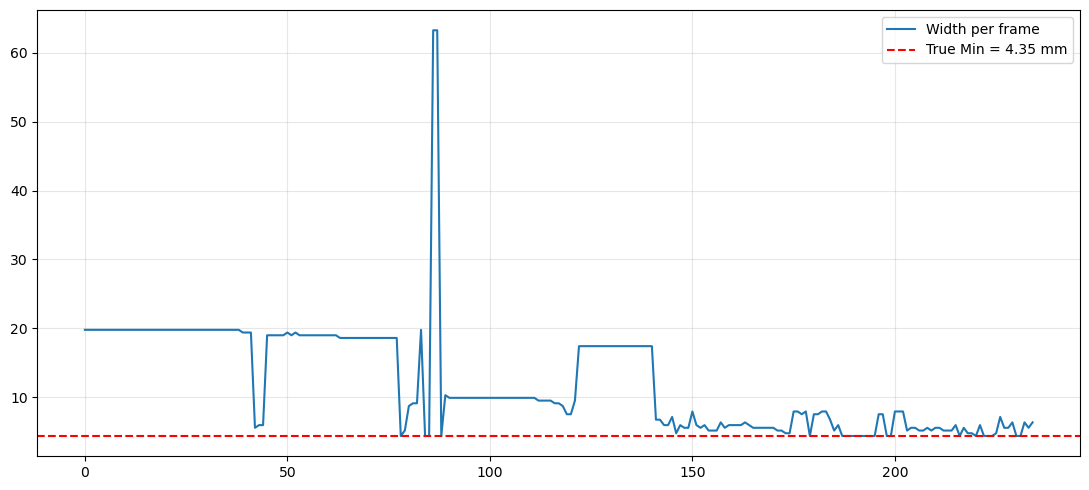

In [6]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import json
import time
from datetime import datetime
import tkinter as tk
from tkinter import messagebox

# ---- 1. Configuration ----
CALIB_IMAGES_DIR = "calibration_images"      
CALIB_PARAMS_FILE = "camera_calibration.json"
CHECKERBOARD = (8, 6)                        # 7x9 බෝඩ් එක සඳහා inner corners (8,6)
SQUARE_SIZE_MM = 25.0                        

SCAN_LOG_CSV = "fabric_width_log.csv"
CAMERA_INDEX = 0

WHITE_THRESHOLD = 200        
WHITE_RATIO_STOP = 0.95      
FABRIC_THRESH = 127          

os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)
print("High-Accuracy Configuration Loaded.")

# ---- 2. Calibration Loader ----
def load_calibration():
    if os.path.exists(CALIB_PARAMS_FILE):
        with open(CALIB_PARAMS_FILE, "r") as f:
            data = json.load(f)
        return np.array(data["camera_matrix"]), np.array(data["dist_coeffs"]), data["pixel_to_mm_scale"]
    return None, None, 1.0

camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

# ---- 3. Core Measurement Functions (HIGH ACCURACY ROW SCAN) ----
def undistort_frame(frame, camera_matrix, dist_coeffs):
    if camera_matrix is None or dist_coeffs is None: return frame
    return cv2.undistort(frame, camera_matrix, dist_coeffs)

def is_white_background(frame, threshold=WHITE_THRESHOLD, white_ratio=WHITE_RATIO_STOP):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return (cv2.countNonZero(thresh) / thresh.size) > white_ratio

def measure_width_px(frame, fabric_thresh=FABRIC_THRESH):
    """
    රෙදි පටියේ වංගු සහ ඇලවීම් මඟ හැර, සෑම පික්සල් පේළියක්ම තිරස්ව මැන 
    නියම අවම පළල (True Minimum Width) සොයා ගන්නා ශ්‍රිතය.
    """
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, fabric_thresh, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None, None

    cnt = max(contours, key=cv2.contourArea)
    if cv2.contourArea(cnt) < 500: return None, None

    # බාහිර ඝෝෂා (Noise) ඉවත් කර රෙදි පටිය පමණක් තෝරා ගැනීමට Mask එකක් සෑදීම
    mask = np.zeros_like(thresh)
    cv2.drawContours(mask, [cnt], -1, 255, -1)
    
    # රෙදි කොටස ඇති සියලුම පික්සල්වල ඛණ්ඩාංක ලබා ගැනීම
    pts = np.where(mask == 255)
    if len(pts[0]) == 0: return None, None
    
    y_indices = np.unique(pts[0])
    min_w = float('inf')
    best_y = None
    best_x_start = None
    
    # රෙදි පටිය ඇති සෑම තිරස් පේළියක්ම (Row by Row) පරික්සීම
    for y in y_indices:
        x_indices = pts[1][pts[0] == y]
        if len(x_indices) > 0:
            w_row = np.max(x_indices) - np.min(x_indices)
            # ඉතා කුඩා දෝෂ මඟහැර පේළියේ අවම අගය යාවත්කාලීන කිරීම
            if w_row < min_w and w_row > 10: 
                min_w = w_row
                best_y = y
                best_x_start = np.min(x_indices)
                
    if min_w == float('inf'): return None, None

    # Global Bounding Box එක වෙනුවට නිවැරදි අවම පේළියේ දත්ත පිටතට ලබාදීම
    x, y, w, h = cv2.boundingRect(cnt) 
    visual_data = (x, y, w, h, best_x_start, best_y, min_w)
    
    return min_w, visual_data

# ---- 4. Post-Scan Analysis & Plotting ----
def analyze_and_plot_scan(csv_path=SCAN_LOG_CSV):
    if not os.path.exists(csv_path): return
    df = pd.read_csv(csv_path)
    if df.empty: return

    min_row = df.loc[df["width_mm"].idxmin()]
    summary = {
        "num_frames": len(df),
        "min_width_mm": float(df["width_mm"].min()),
        "min_width_frame": int(min_row["frame"]),
        "max_width_mm": float(df["width_mm"].max()),
        "mean_width_mm": float(df["width_mm"].mean()),
    }

    print("\n=== High-Accuracy Scan Summary ===")
    print(f"Minimum Width   : {summary['min_width_mm']:.2f} mm  (Frame {summary['min_width_frame']})")
    print(f"Mean Width      : {summary['mean_width_mm']:.2f} mm")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df["frame"], df["width_mm"], color="#1f77b4", label="Width per frame")
    ax.axhline(summary["min_width_mm"], color="red", linestyle="--", label=f"True Min = {summary['min_width_mm']:.2f} mm")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fabric_width_profile.png", dpi=150)
    plt.show(block=False)
    plt.pause(3)
    plt.close()

# ---- 5. Live Capture & Scan Loop ----
def run_scan(camera_index=CAMERA_INDEX, show_preview=True):
    global camera_matrix, dist_coeffs, pixel_to_mm_scale
    camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened(): raise RuntimeError("Could not open camera.")

    records = []
    frame_idx = 0
    print("Advanced Scan Started...")

    while True:
        ret, frame = cap.read()
        if not ret: break

        frame_u = undistort_frame(frame, camera_matrix, dist_coeffs)
        if is_white_background(frame_u): break

        width_px, visual_data = measure_width_px(frame_u)
        if width_px is not None:
            width_mm = width_px * pixel_to_mm_scale
            records.append({
                "frame": frame_idx,
                "timestamp": datetime.now().isoformat(),
                "width_px": width_px,
                "width_mm": round(width_mm, 2),
            })
            
            if show_preview:
                x, y, w, h, bx, by, mw = visual_data
                # මුළු කොටුවම රතු පැහැයෙන් (පැරණි ක්‍රමය පෙන්වීමට)
                cv2.rectangle(frame_u, (x, y), (x + w, y + h), (0, 0, 255), 1)
                # නිවැරදි අවම පළල මැනගත් තිරස් පේළිය කොළ පැහැයෙන්
                cv2.line(frame_u, (bx, by), (bx + int(mw), by), (0, 255, 0), 3)
                cv2.putText(frame_u, f"True Min: {width_mm:.1f} mm", (x, max(y - 10, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

        if show_preview:
            cv2.imshow("Advanced Fabric Scan", frame_u)
            if cv2.waitKey(1) & 0xFF == ord('q'): break
        frame_idx += 1

    cap.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(SCAN_LOG_CSV, index=False)
    analyze_and_plot_scan()

# ---- 6. GUI Setup ----
def launch_start_gui(on_start_callback):
    root = tk.Tk()
    root.title("Fabric Roll Width Scanner")
    root.geometry("360x220")
    
    status_var = tk.StringVar(value="Ready to scan curved/slanted fabric.")

    tk.Label(root, text="Fabric Scanner (Row-Scan Enabled)", font=("Segoe UI", 11, "bold")).pack(pady=10)
    tk.Label(root, textvariable=status_var, fg="#333", wraplength=320).pack(pady=5)
    
    tk.Button(root, text="Start Fabric Scan", command=on_start_callback, bg="#2e7d32", fg="white", width=25, height=2).pack(pady=10)
    tk.Button(root, text="Close", command=root.destroy, width=15).pack(pady=5)

    root.mainloop()

if __name__ == "__main__":
    launch_start_gui(run_scan)

Center-Line Scan Configuration Loaded.
Center-Line Scan Started...

=== Center-Line Scan Summary ===
Minimum Width   : 10.28 mm  (Frame 881)
Mean Width      : 224.17 mm


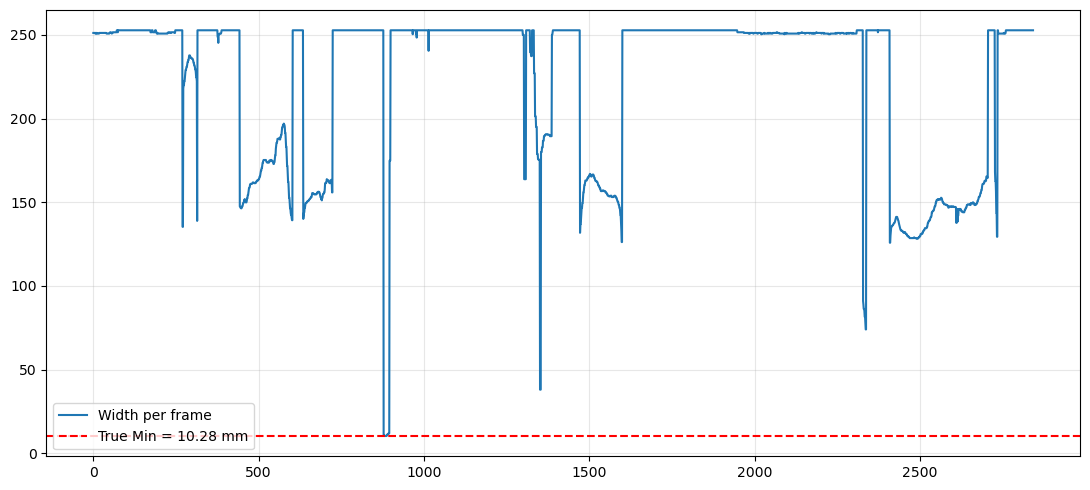

In [4]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import json
import time
from datetime import datetime
import tkinter as tk
from tkinter import messagebox

# ---- 1. Configuration ----
CALIB_IMAGES_DIR = "calibration_images"      
CALIB_PARAMS_FILE = "camera_calibration.json"
CHECKERBOARD = (8, 6)                        # 7x9 බෝඩ් එක සඳහා inner corners (8,6)
SQUARE_SIZE_MM = 25.0                        

SCAN_LOG_CSV = "fabric_width_log.csv"
CAMERA_INDEX = 0

WHITE_THRESHOLD = 200        
WHITE_RATIO_STOP = 0.95      
FABRIC_THRESH = 127          

os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)
print("Center-Line Scan Configuration Loaded.")

# ---- 2. Calibration Loader ----
def load_calibration():
    if os.path.exists(CALIB_PARAMS_FILE):
        with open(CALIB_PARAMS_FILE, "r") as f:
            data = json.load(f)
        return np.array(data["camera_matrix"]), np.array(data["dist_coeffs"]), data["pixel_to_mm_scale"]
    return None, None, 1.0

camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

# ---- 3. Core Measurement Functions (CENTER LINE SCAN) ----
def undistort_frame(frame, camera_matrix, dist_coeffs):
    if camera_matrix is None or dist_coeffs is None: return frame
    return cv2.undistort(frame, camera_matrix, dist_coeffs)

def is_white_background(frame, threshold=WHITE_THRESHOLD, white_ratio=WHITE_RATIO_STOP):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return (cv2.countNonZero(thresh) / thresh.size) > white_ratio

def measure_width_px(frame, fabric_thresh=FABRIC_THRESH):
    """
    කැමරා රාමුවේ හරි මැද ඇති එකම එක තිරස් පේළිය (Center Row) පමණක් 
    පරීක්ෂා කර රෙදි පටියේ පළල මනින ශ්‍රිතය.
    """
    h_frame, w_frame = frame.shape[:2]
    center_y = h_frame // 2  # කැමරාවේ හරි මැද තිරස් ඛණ්ඩාංකය (Center Y)

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, fabric_thresh, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    # කැමරාවේ මැද පේළියට (center_y) අදාළ පික්සල් පේළිය පමණක් ලබා ගැනීම
    row_pixels = thresh[center_y, :]
    
    # රෙදි කොටස පවතින (සුදු නොවන/Binary INV නිසා 255 වන) ස්ථාන සෙවීම
    fabric_indices = np.where(row_pixels == 255)[0]
    
    if len(fabric_indices) == 0: 
        return None, None

    # රෙදි පටිය ආරම්භ වන සහ අවසන් වන තැන් අතර වෙනස (පළල පික්සල් වලින්)
    x_start = int(np.min(fabric_indices))
    x_end = int(np.max(fabric_indices))
    width_px = x_end - x_start

    if width_px < 10:  # ඉතා කුඩා දෝෂ (Noise) මඟහැරීමට
        return None, None

    visual_data = (x_start, x_end, center_y, w_frame)
    return width_px, visual_data

# ---- 4. Post-Scan Analysis & Plotting ----
def analyze_and_plot_scan(csv_path=SCAN_LOG_CSV):
    if not os.path.exists(csv_path): return
    df = pd.read_csv(csv_path)
    if df.empty: return

    min_row = df.loc[df["width_mm"].idxmin()]
    summary = {
        "num_frames": len(df),
        "min_width_mm": float(df["width_mm"].min()),
        "min_width_frame": int(min_row["frame"]),
        "max_width_mm": float(df["width_mm"].max()),
        "mean_width_mm": float(df["width_mm"].mean()),
    }

    print("\n=== Center-Line Scan Summary ===")
    print(f"Minimum Width   : {summary['min_width_mm']:.2f} mm  (Frame {summary['min_width_frame']})")
    print(f"Mean Width      : {summary['mean_width_mm']:.2f} mm")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df["frame"], df["width_mm"], color="#1f77b4", label="Width per frame")
    ax.axhline(summary["min_width_mm"], color="red", linestyle="--", label=f"True Min = {summary['min_width_mm']:.2f} mm")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fabric_width_profile.png", dpi=150)
    plt.show(block=False)
    plt.pause(3)
    plt.close()

# ---- 5. Live Capture & Scan Loop ----
def run_scan(camera_index=CAMERA_INDEX, show_preview=True):
    global camera_matrix, dist_coeffs, pixel_to_mm_scale
    camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened(): raise RuntimeError("Could not open camera.")

    records = []
    frame_idx = 0
    print("Center-Line Scan Started...")

    while True:
        ret, frame = cap.read()
        if not ret: break

        frame_u = undistort_frame(frame, camera_matrix, dist_coeffs)
        if is_white_background(frame_u): break

        width_px, visual_data = measure_width_px(frame_u)
        if width_px is not None:
            width_mm = width_px * pixel_to_mm_scale
            records.append({
                "frame": frame_idx,
                "timestamp": datetime.now().isoformat(),
                "width_px": width_px,
                "width_mm": round(width_mm, 2),
            })
            
            if show_preview:
                x_start, x_end, center_y, w_frame = visual_data
                # කැමරාවේ මුළු මැද රේඛාවම නිල් පැහැයෙන් ඇඳීම (Guide Line)
                cv2.line(frame_u, (0, center_y), (w_frame, center_y), (255, 0, 0), 1)
                # මනිනු ලබන රෙදි කොටස පමණක් ඝන කොළ පැහැති රේඛාවකින් (Measured Line)
                cv2.line(frame_u, (x_start, center_y), (x_end, center_y), (0, 255, 0), 3)
                # දෙකෙළවර ලකුණු කිරීම
                cv2.circle(frame_u, (x_start, center_y), 4, (0, 0, 255), -1)
                cv2.circle(frame_u, (x_end, center_y), 4, (0, 0, 255), -1)
                
                cv2.putText(frame_u, f"Center Width: {width_mm:.1f} mm", (x_start, max(center_y - 15, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        if show_preview:
            cv2.imshow("Center-Line Fabric Scan", frame_u)
            if cv2.waitKey(1) & 0xFF == ord('q'): break
        frame_idx += 1

    cap.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(SCAN_LOG_CSV, index=False)
    analyze_and_plot_scan()

# ---- 6. GUI Setup ----
def launch_start_gui(on_start_callback):
    root = tk.Tk()
    root.title("Fabric Roll Width Scanner")
    root.geometry("360x220")
    
    status_var = tk.StringVar(value="Scanning active ONLY at frame center.")

    tk.Label(root, text="Fabric Scanner (Center-Line Mode)", font=("Segoe UI", 11, "bold")).pack(pady=10)
    tk.Label(root, textvariable=status_var, fg="#333", wraplength=320).pack(pady=5)
    
    tk.Button(root, text="Start Center-Line Scan", command=on_start_callback, bg="#2e7d32", fg="white", width=25, height=2).pack(pady=10)
    tk.Button(root, text="Close", command=root.destroy, width=15).pack(pady=5)

    root.mainloop()

if __name__ == "__main__":
    launch_start_gui(run_scan)

Crop Configuration Loaded.
Cropped Center-Line Scan Started...

=== Scan Summary (Cropped Mode) ===
Minimum Width   : 3.95 mm
Mean Width      : 116.99 mm


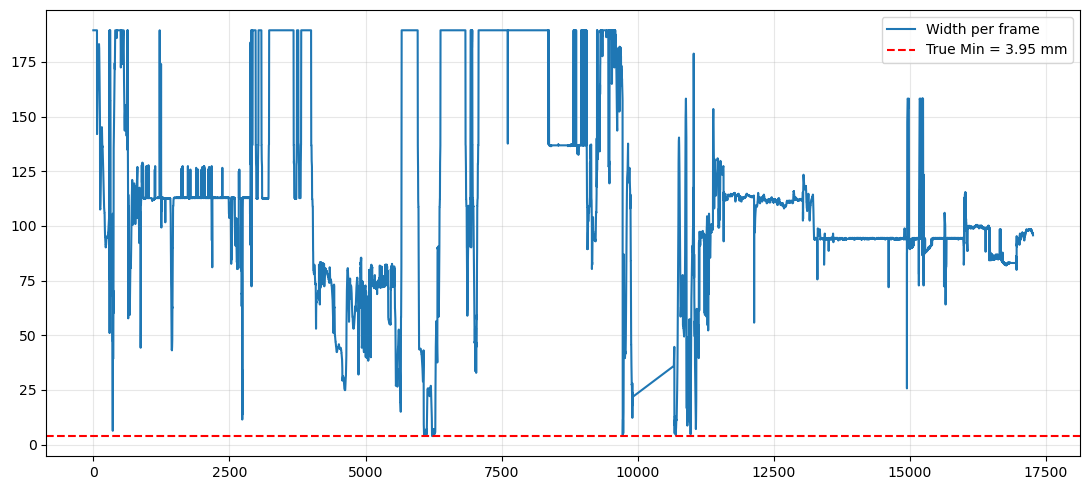

In [1]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import json
import time
from datetime import datetime
import tkinter as tk
from tkinter import messagebox

# ---- 1. Configuration ----
CALIB_IMAGES_DIR = "calibration_images"      
CALIB_PARAMS_FILE = "camera_calibration.json"
CHECKERBOARD = (8, 6)                        
SQUARE_SIZE_MM = 25.0                        

SCAN_LOG_CSV = "fabric_width_log.csv"
CAMERA_INDEX = 0

WHITE_THRESHOLD = 200        
WHITE_RATIO_STOP = 0.95      
FABRIC_THRESH = 127          

# !!! [NEW CONFIGURATION] පැති 4න් Crop කළ යුතු පික්සල් ගණන මෙතැනින් වෙනස් කරන්න !!!
CROP_TOP = 50       # ඉහළින් ඉවත් කරන පික්සල් ගණන
CROP_BOTTOM = 50    # පහළින් ඉවත් කරන පික්සල් ගණන
CROP_LEFT = 80      # වමෙන් ඉවත් කරන පික්සල් ගණන
CROP_RIGHT = 80     # දකුණෙන් ඉවත් කරන පික්සල් ගණන

os.makedirs(CALIB_IMAGES_DIR, exist_ok=True)
print("Crop Configuration Loaded.")

# ---- 2. Calibration Loader ----
def load_calibration():
    if os.path.exists(CALIB_PARAMS_FILE):
        with open(CALIB_PARAMS_FILE, "r") as f:
            data = json.load(f)
        return np.array(data["camera_matrix"]), np.array(data["dist_coeffs"]), data["pixel_to_mm_scale"]
    return None, None, 1.0

camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

# ---- 3. Core Measurement Functions (WITH IMAGE CROPPING) ----
def crop_frame(frame):
    """ලබාගන්නා Frame එක පැති 4න් Crop කරන ශ්‍රිතය."""
    h_frame, w_frame = frame.shape[:2]
    
    # නව මායිම් ගණනය කිරීම (Array Slicing සඳහා)
    start_y = CROP_TOP
    end_y = h_frame - CROP_BOTTOM
    start_x = CROP_LEFT
    end_x = w_frame - CROP_RIGHT
    
    # ආරක්ෂිත පියවරක් ලෙස මායිම් නිවැරදිදැයි බැලීම
    if start_y >= end_y or start_x >= end_x:
        return frame # Crop අගයන් විශාල වැඩි නම් මුල් රූපයම ලබා දේ
        
    return frame[start_y:end_y, start_x:end_x]

def undistort_frame(frame, camera_matrix, dist_coeffs):
    if camera_matrix is None or dist_coeffs is None: return frame
    return cv2.undistort(frame, camera_matrix, dist_coeffs)

def is_white_background(frame, threshold=WHITE_THRESHOLD, white_ratio=WHITE_RATIO_STOP):
    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold, 255, cv2.THRESH_BINARY)
    return (cv2.countNonZero(thresh) / thresh.size) > white_ratio

def measure_width_px(frame, fabric_thresh=FABRIC_THRESH):
    """Crop කරන ලද Frame එකෙහි හරි මැද පේළිය පමණක් මැනීම."""
    h_frame, w_frame = frame.shape[:2]
    center_y = h_frame // 2  # Crop කරන ලද රූපයේ හරි මැද Y ඛණ්ඩාංකය

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, fabric_thresh, 255, cv2.THRESH_BINARY_INV)

    kernel = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)

    row_pixels = thresh[center_y, :]
    fabric_indices = np.where(row_pixels == 255)[0]
    
    if len(fabric_indices) == 0: 
        return None, None

    x_start = int(np.min(fabric_indices))
    x_end = int(np.max(fabric_indices))
    width_px = x_end - x_start

    if width_px < 10: 
        return None, None

    visual_data = (x_start, x_end, center_y, w_frame)
    return width_px, visual_data

# ---- 4. Post-Scan Analysis & Plotting ----
def analyze_and_plot_scan(csv_path=SCAN_LOG_CSV):
    if not os.path.exists(csv_path): return
    df = pd.read_csv(csv_path)
    if df.empty: return

    min_row = df.loc[df["width_mm"].idxmin()]
    summary = {
        "num_frames": len(df),
        "min_width_mm": float(df["width_mm"].min()),
        "min_width_frame": int(min_row["frame"]),
        "max_width_mm": float(df["width_mm"].max()),
        "mean_width_mm": float(df["width_mm"].mean()),
    }

    print("\n=== Scan Summary (Cropped Mode) ===")
    print(f"Minimum Width   : {summary['min_width_mm']:.2f} mm")
    print(f"Mean Width      : {summary['mean_width_mm']:.2f} mm")

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.plot(df["frame"], df["width_mm"], color="#1f77b4", label="Width per frame")
    ax.axhline(summary["min_width_mm"], color="red", linestyle="--", label=f"True Min = {summary['min_width_mm']:.2f} mm")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig("fabric_width_profile.png", dpi=150)
    plt.show(block=False)
    plt.pause(3)
    plt.close()

# ---- 5. Live Capture & Scan Loop ----
def run_scan(camera_index=CAMERA_INDEX, show_preview=True):
    global camera_matrix, dist_coeffs, pixel_to_mm_scale
    camera_matrix, dist_coeffs, pixel_to_mm_scale = load_calibration()

    cap = cv2.VideoCapture(camera_index)
    if not cap.isOpened(): raise RuntimeError("Could not open camera.")

    records = []
    frame_idx = 0
    print("Cropped Center-Line Scan Started...")

    while True:
        ret, frame = cap.read()
        if not ret: break

        # 1. 🔍 Distortion නිවැරදි කිරීම
        frame_u = undistort_frame(frame, camera_matrix, dist_coeffs)
        
        # 2. ✂️ පැති හතර Crop කිරීම (මිනුම් ගැනීමට පෙර සිදු කරයි)
        frame_cropped = crop_frame(frame_u)

        # 3. ⬜ පසුබිම පරීක්ෂා කිරීම (Crop කරන ලද කොටස මත පමණක් ක්‍රියාත්මක වේ)
        if is_white_background(frame_cropped): break

        # 4. 🎯 මැදින් පළල මැනීම
        width_px, visual_data = measure_width_px(frame_cropped)
        if width_px is not None:
            width_mm = width_px * pixel_to_mm_scale
            records.append({
                "frame": frame_idx,
                "timestamp": datetime.now().isoformat(),
                "width_px": width_px,
                "width_mm": round(width_mm, 2),
            })
            
            if show_preview:
                x_start, x_end, center_y, w_frame = visual_data
                # කැමරාවේ මැද රේඛාව (නිල්)
                cv2.line(frame_cropped, (0, center_y), (w_frame, center_y), (255, 0, 0), 1)
                # මනින කොටස (කොළ)
                cv2.line(frame_cropped, (x_start, center_y), (x_end, center_y), (0, 255, 0), 3)
                cv2.circle(frame_cropped, (x_start, center_y), 4, (0, 0, 255), -1)
                cv2.circle(frame_cropped, (x_end, center_y), 4, (0, 0, 255), -1)
                
                cv2.putText(frame_cropped, f"Width: {width_mm:.1f} mm", (x_start, max(center_y - 15, 20)),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

        if show_preview:
            # Crop කරන ලද නව දර්ශනය පමණක් preview එකෙහි පෙන්වයි
            cv2.imshow("Cropped Fabric Scan", frame_cropped)
            if cv2.waitKey(1) & 0xFF == ord('q'): break
        frame_idx += 1

    cap.release()
    cv2.destroyAllWindows()

    df = pd.DataFrame(records)
    df.to_csv(SCAN_LOG_CSV, index=False)
    analyze_and_plot_scan()

# ---- 6. GUI Setup ----
def launch_start_gui(on_start_callback):
    root = tk.Tk()
    root.title("Fabric Roll Width Scanner")
    root.geometry("360x220")
    
    status_var = tk.StringVar(value="Cropped view mode active.")

    tk.Label(root, text="Fabric Scanner (Cropped & Center-Line)", font=("Segoe UI", 11, "bold")).pack(pady=10)
    tk.Label(root, textvariable=status_var, fg="#333", wraplength=320).pack(pady=5)
    
    tk.Button(root, text="Start Cropped Scan", command=on_start_callback, bg="#2e7d32", fg="white", width=25, height=2).pack(pady=10)
    tk.Button(root, text="Close", command=root.destroy, width=15).pack(pady=5)

    root.mainloop()

if __name__ == "__main__":
    launch_start_gui(run_scan)